# Project: MSM comparison of Ac-AV-NHMe and Ac-VA-NHMe dimer

##  Import Packages and Load Data

In [310]:
import pyemma
import deeptime
import numpy as np
import matplotlib.pyplot as plt
import random
from deeptime.clustering import KMeans
from tqdm.notebook import tqdm
from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM
from deeptime.markov.msm import BayesianMSM
from deeptime.util.validation import implied_timescales
from deeptime.plots import plot_implied_timescales
from deeptime.plots import plot_ck_test
plt.matplotlib.rcParams.update({'font.size': 16})
dihedral_AV = np.load("/Users/meo/markov/dimer1/dihedral_AV.npy")
dihedral_VA = np.load("/Users/meo/markov/dimer1/dihedral_VA.npy")

In [308]:
dihedral_AV.shape

(1000001, 4)

## Plot Trajectories Seperately

In [307]:
ALA_dihedral_AV = dihedral_AV[:,0:2]
VAL_dihedral_AV = dihedral_AV[:,2:4]
#ALA_dihedral_VA = dihedral_VA[:,0:2]
#VAL_dihedral_VA = dihedral_VA[:,2:4]
#pyemma.plots.plot_free_energy(ALA_dihedral_AV[:,0], ALA_dihedral_AV[:,1])
#pyemma.plots.plot_free_energy(VAL_dihedral_AV[:,0], VAL_dihedral_AV[:,1])
#pyemma.plots.plot_free_energy(ALA_dihedral_VA[:,0], ALA_dihedral_VA[:,1])
#pyemma.plots.plot_free_energy(VAL_dihedral_VA[:,0], VAL_dihedral_VA[:,1])

In [327]:
'''
sample = 100
x = range(sample)
y1 = dihedral_AV[np.array(random.sample(range(1000000),sample)),0]
y2 = dihedral_AV[np.array(random.sample(range(1000000),sample)),0]
y3 = dihedral_AV[np.array(random.sample(range(1000000),sample)),0]
y4 = dihedral_AV[np.array(random.sample(range(1000000),sample)),0]
plt.plot(x,y1)
plt.plot(x,y2)
#plt.plot(x,y3)
#plt.plot(x,y4)
#fig, axes = plt.subplots(4, 1, figsize=(12, 10))
#axes[0,0] = plt.plot(x,y1)
#axes[1,0] = plt.plot(x,y2)
'''

'\nsample = 100\nx = range(sample)\ny1 = dihedral_AV[np.array(random.sample(range(1000000),sample)),0]\ny2 = dihedral_AV[np.array(random.sample(range(1000000),sample)),0]\ny3 = dihedral_AV[np.array(random.sample(range(1000000),sample)),0]\ny4 = dihedral_AV[np.array(random.sample(range(1000000),sample)),0]\nplt.plot(x,y1)\nplt.plot(x,y2)\n#plt.plot(x,y3)\n#plt.plot(x,y4)\n#fig, axes = plt.subplots(4, 1, figsize=(12, 10))\n#axes[0,0] = plt.plot(x,y1)\n#axes[1,0] = plt.plot(x,y2)\n'

## Discretization

### How many cluster centers do we need?

In [ ]:
## For Alanine monomer

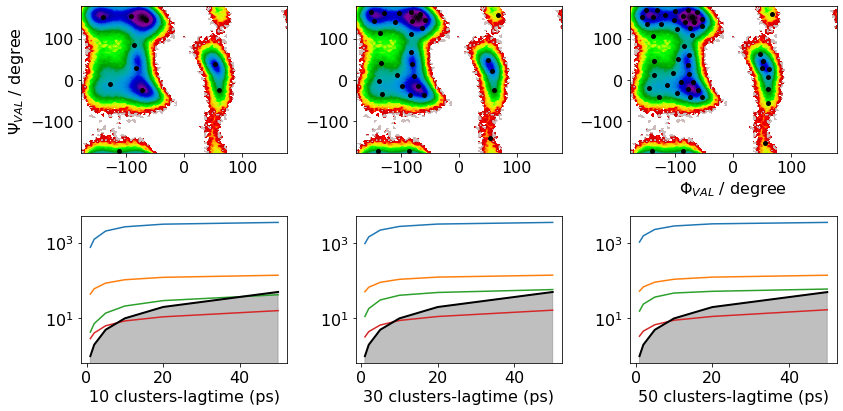

In [251]:
def its_msm(data, lagtimes):
    models = [MaximumLikelihoodMSM(lagtime=lag).fit_fetch(data) for lag in lagtimes]
    return implied_timescales(models)

lags = [1, 2, 5, 10, 20, 50]

ALA_cluster_10 = KMeans(10, max_iter=200).fit_fetch(ALA_dihedral_AV[::10])
ALA_its_10 = its_msm(cluster_50.transform(ALA_dihedral_AV), lags)

ALA_cluster_30 = KMeans(30, max_iter=200).fit_fetch(ALA_dihedral_AV[::10])
ALA_its_30 = its_msm(cluster_100.transform(ALA_dihedral_AV), lags)

ALA_cluster_50 = KMeans(50, max_iter=200).fit_fetch(ALA_dihedral_AV[::10])
ALA_its_50 = its_msm(cluster_200.transform(ALA_dihedral_AV), lags)

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

pyemma.plots.plot_free_energy(*ALA_dihedral_AV.T, ax=axes[0, 0], cbar=False)
axes[0, 0].scatter(*ALA_cluster_10.cluster_centers.T, s=15, c='k')

axes[0, 0].set_ylabel('$\Psi_{VAL}$ / degree')
ax_its = plot_implied_timescales(ALA_its_10, ax=axes[1, 0], n_its=4)
ax_its.set_yscale('log')
ax_its.set_xlabel('10 clusters-lagtime (ps)')

pyemma.plots.plot_free_energy(*ALA_dihedral_AV.T, ax=axes[0, 1], cbar=False)
axes[0, 1].scatter(*ALA_cluster_30.cluster_centers.T, s=15, c='k')

ax_its = plot_implied_timescales(ALA_its_30, ax=axes[1, 1], n_its=4)
ax_its.set_yscale('log')
ax_its.set_xlabel('30 clusters-lagtime (ps)')

pyemma.plots.plot_free_energy(*ALA_dihedral_AV.T, ax=axes[0, 2], cbar=False)
axes[0, 2].scatter(*ALA_cluster_50.cluster_centers.T, s=15, c='k')
axes[0, 2].set_xlabel('$\Phi_{VAL}$ / degree')

ax_its = plot_implied_timescales(ALA_its_50, ax=axes[1, 2], n_its=4)
ax_its.set_yscale('log')
ax_its.set_xlabel('50 clusters-lagtime (ps)')

fig.tight_layout()

In [252]:
## For Valine monomer

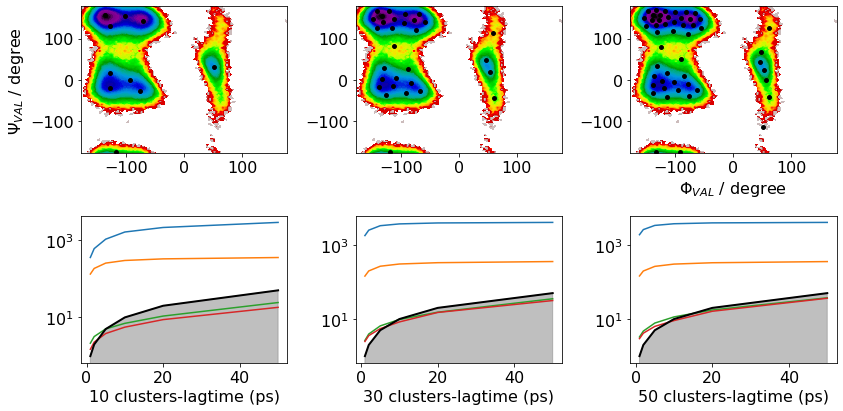

In [261]:

VAL_cluster_10 = KMeans(10, max_iter=200).fit_fetch(VAL_dihedral_AV[::10])
VAL_its_10 = its_msm(VAL_cluster_10.transform(VAL_dihedral_AV), lags)

VAL_cluster_30 = KMeans(30, max_iter=200).fit_fetch(VAL_dihedral_AV[::10])
VAL_its_30 = its_msm(VAL_cluster_30.transform(VAL_dihedral_AV), lags)

VAL_cluster_50 = KMeans(50, max_iter=200).fit_fetch(VAL_dihedral_AV[::10])
VAL_its_50 = its_msm(VAL_cluster_50.transform(VAL_dihedral_AV), lags)

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

pyemma.plots.plot_free_energy(*VAL_dihedral_AV.T, ax=axes[0, 0], cbar=False)
axes[0, 0].scatter(*VAL_cluster_10.cluster_centers.T, s=15, c='k')

axes[0, 0].set_ylabel('$\Psi_{VAL}$ / degree')
ax_its = plot_implied_timescales(VAL_its_10, ax=axes[1, 0], n_its=4)
ax_its.set_yscale('log')
ax_its.set_xlabel('10 clusters-lagtime (ps)')

pyemma.plots.plot_free_energy(*VAL_dihedral_AV.T, ax=axes[0, 1], cbar=False)
axes[0, 1].scatter(*VAL_cluster_30.cluster_centers.T, s=15, c='k')

ax_its = plot_implied_timescales(VAL_its_30, ax=axes[1, 1], n_its=4)
ax_its.set_yscale('log')
ax_its.set_xlabel('30 clusters-lagtime (ps)')

pyemma.plots.plot_free_energy(*VAL_dihedral_AV.T, ax=axes[0, 2], cbar=False)
axes[0, 2].scatter(*VAL_cluster_50.cluster_centers.T, s=15, c='k')
axes[0, 2].set_xlabel('$\Phi_{VAL}$ / degree')

ax_its = plot_implied_timescales(VAL_its_50, ax=axes[1, 2], n_its=4)
ax_its.set_yscale('log')
ax_its.set_xlabel('50 clusters-lagtime (ps)')

fig.tight_layout()

### Estimate the Maximum Likelihood Markov Model

In [264]:
ALA_AV_dtrajs = ALA_cluster_30.transform(ALA_dihedral_AV) 
VAL_AV_dtrajs = VAL_cluster_30.transform(VAL_dihedral_AV) 
counts_estimator = TransitionCountEstimator(lagtime=10, count_mode='sliding')
ALA_AV_counts = counts_estimator.fit_fetch(ALA_AV_dtrajs).submodel_largest()
VAL_AV_counts = counts_estimator.fit_fetch(VAL_AV_dtrajs).submodel_largest()
msm_estimator = MaximumLikelihoodMSM()
ALA_AV_msm = msm_estimator.fit_fetch(ALA_AV_counts)
VAL_AV_msm = msm_estimator.fit_fetch(VAL_AV_counts)

print(f'fraction of states used(ALA) = {ALA_AV_msm.state_fraction}')
print(f'fraction of states used(ALA) = {ALA_AV_msm.state_fraction}')
print(f'fraction of counts used(VAL) = {VAL_AV_msm.count_fraction}')
print(f'fraction of counts used(VAL)= {VAL_AV_msm.count_fraction}')

fraction of states used(ALA) = 1.0
fraction of states used(ALA) = 1.0
fraction of counts used(VAL) = 1.0
fraction of counts used(VAL)= 1.0


### Visualize the right eigenvectors

In [ ]:
## Alanine 

first eigenvector is one: True (min=0.9999999999999675, max=1.0000000000004008)


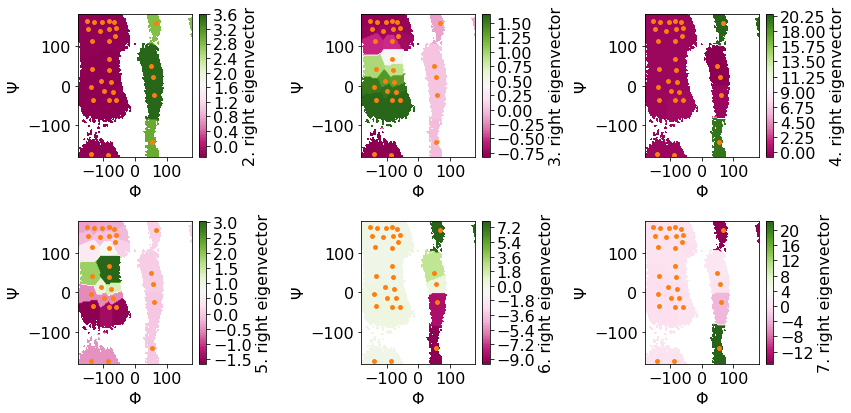

In [272]:
eigvec = ALA_AV_msm.eigenvectors_right()
print('first eigenvector is one: {} (min={}, max={})'.format(
    np.allclose(eigvec[:, 0], 1, atol=1e-15), eigvec[:, 0].min(), eigvec[:, 0].max()))

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    pyemma.plots.plot_contour(
        *ALA_dihedral_AV.T, eigvec[ALA_AV_dtrajs, i + 1], ax=ax, cmap='PiYG',
        cbar_label='{}. right eigenvector'.format(i + 2), mask=True)
    ax.scatter(*ALA_cluster_30.cluster_centers.T, s=15, c='C1')
    ax.set_xlabel('$\Phi$')
    ax.set_ylabel('$\Psi$')
fig.tight_layout()

In [ ]:
## Valnine 

first eigenvector is one: True (min=0.9999999999999877, max=1.000000000000122)


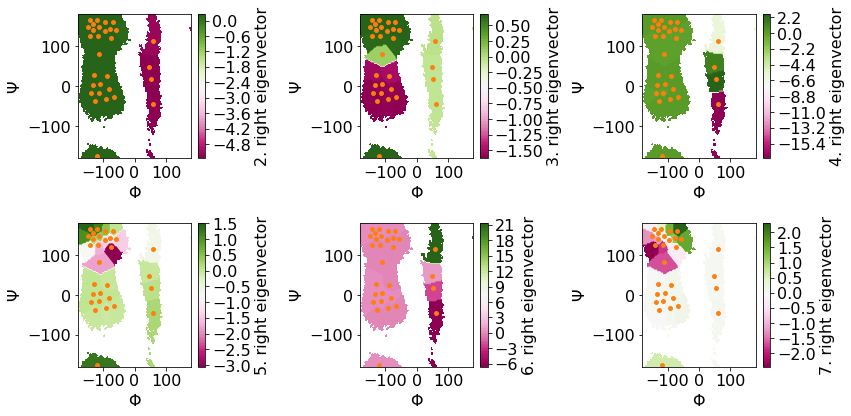

In [273]:
eigvec = VAL_AV_msm.eigenvectors_right()
print('first eigenvector is one: {} (min={}, max={})'.format(
    np.allclose(eigvec[:, 0], 1, atol=1e-15), eigvec[:, 0].min(), eigvec[:, 0].max()))

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    pyemma.plots.plot_contour(
        *VAL_dihedral_AV.T, eigvec[VAL_AV_dtrajs, i + 1], ax=ax, cmap='PiYG',
        cbar_label='{}. right eigenvector'.format(i + 2), mask=True)
    ax.scatter(*VAL_cluster_30.cluster_centers.T, s=15, c='C1')
    ax.set_xlabel('$\Phi$')
    ax.set_ylabel('$\Psi$')
fig.tight_layout()

### CK-test

In [ ]:
## Alaine

/Users/meo/opt/miniconda3/envs/workshop/lib/python3.9/site-packages/deeptime/plots/chapman_kolmogorov.py:173: ComplexWarning: Your CKtest contains imaginary components which are ignored during plotting.
  warnings.warn("Your CKtest contains imaginary components which are ignored during plotting.",


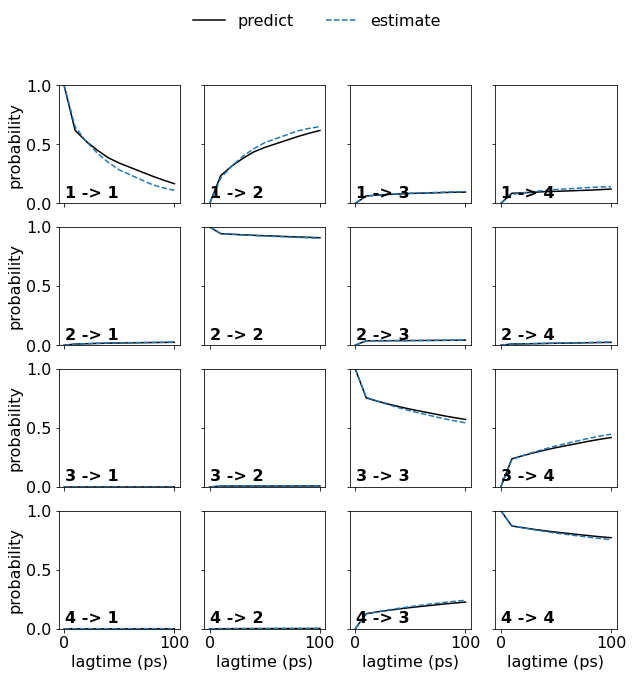

In [267]:
test_model = MaximumLikelihoodMSM(lagtime=10).fit_fetch(ALA_AV_dtrajs);
ALA_AV_models = []
for lagtime in [10, 20, 30, 40, 50, 80, 90, 100]:
    ALA_AV_models.append(MaximumLikelihoodMSM(lagtime=lagtime).fit_fetch(ALA_AV_dtrajs))
ck_test = test_model.ck_test(ALA_AV_models, n_metastable_sets=4)
plot_ck_test(ck_test, xlabel='lagtime (ps)', sharey=True);

In [275]:
## Valine

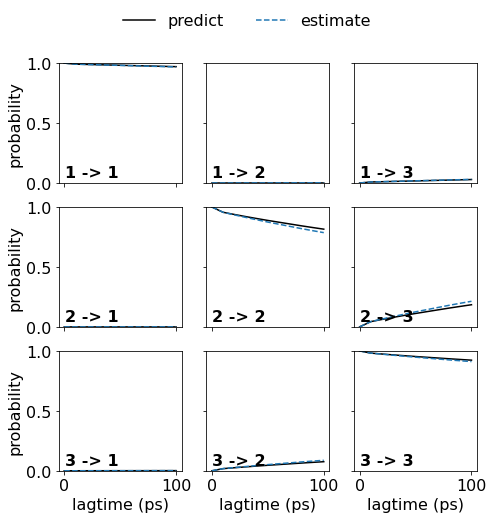

In [269]:
test_model = MaximumLikelihoodMSM(lagtime=10).fit_fetch(VAL_AV_dtrajs);
VAL_AV_models = []
for lagtime in [10, 20, 30, 40, 50, 80, 90, 100]:
    VAL_AV_models.append(MaximumLikelihoodMSM(lagtime=lagtime).fit_fetch(VAL_AV_dtrajs))
ck_test = test_model.ck_test(VAL_AV_models, n_metastable_sets=3)
plot_ck_test(ck_test, xlabel='lagtime (ps)', sharey=True);

## Combine System the Dimer

### K-Means For the Dimer System

In [335]:
cluster_AV_kmeans = KMeans(50, max_iter=200, progress=tqdm)\
    .fit_fetch(dihedral_AV[::10])
lags = [20, 40, 60, 80, 100, 120, 140, 160, 180, 200]
its_AV_kmeans = its_msm(cluster_AV_kmeans.transform(dihedral_AV), lags)


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

In [347]:
dihedral_AV

array([[ -74.7985 ,   -7.11858,  -61.1341 ,  -14.7172 ],
       [ -79.3686 ,   55.7628 , -108.999  ,   21.2576 ],
       [ -70.0143 ,   57.3046 ,  -90.0208 ,   36.9192 ],
       ...,
       [ -79.4198 ,  162.771  , -120.156  ,  133.68   ],
       [ -42.7457 ,  133.797  , -109.526  ,  146.128  ],
       [ -64.6063 ,  177.092  , -132.905  ,  176.092  ]])

In [336]:
from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM

dtrajs_AV_kmeans = cluster_AV_kmeans.transform(dihedral_AV) 


models = []
for lag in tqdm(lags, leave=False):
    counts_estimator = TransitionCountEstimator(lag, "sliding")
    counts = counts_estimator.fit_fetch(dtrajs)
    counts = counts.submodel_largest()
    msm_estimator = MaximumLikelihoodMSM()
    models.append(msm_estimator.fit_fetch(counts))

  0%|          | 0/10 [00:00<?, ?it/s]

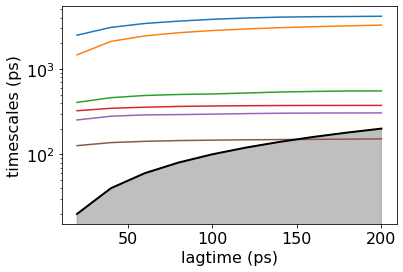

In [337]:
from deeptime.util.validation import implied_timescales
from deeptime.plots import plot_implied_timescales

its = implied_timescales(models)
ax = plot_implied_timescales(its, n_its=6)
ax.set_yscale('log')
ax.set_xlabel('lagtime (ps)')
ax.set_ylabel('timescales (ps)');

In [338]:
#dtrajs = cluster_AV_kmeans.transform(dihedral_AV)
msm = MaximumLikelihoodMSM(lagtime=10).fit_fetch(dtrajs_AV_kmeans)
print('fraction of states used = {:f}'.format(msm.state_fraction))
print('fraction of counts used = {:f}'.format(msm.count_fraction))



fraction of states used = 1.000000
fraction of counts used = 1.000000


first eigenvector is one: True (min=0.9999999999999643, max=1.0000000000001097)


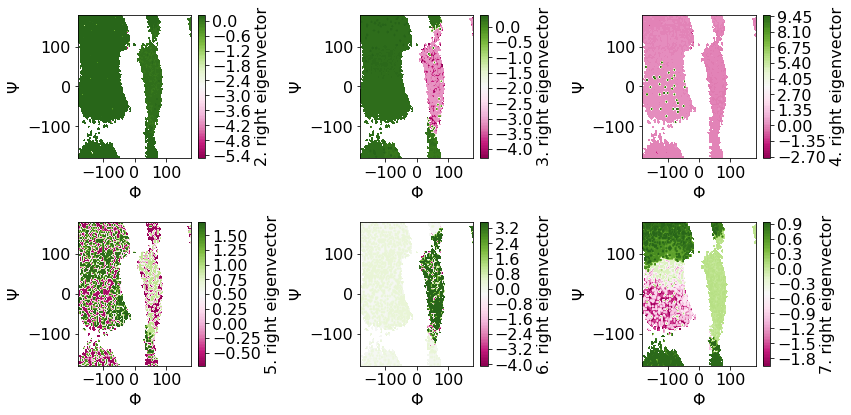

In [340]:
eigvec = msm.eigenvectors_right()
print('first eigenvector is one: {} (min={}, max={})'.format(
    np.allclose(eigvec[:, 0], 1, atol=1e-15), eigvec[:, 0].min(), eigvec[:, 0].max()))

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    pyemma.plots.plot_contour(
        *ALA_dihedral_AV.T, eigvec[dtrajs_AV_kmeans, i + 1], ax=ax, cmap='PiYG',
        cbar_label='{}. right eigenvector'.format(i + 2), mask=True)
    #ax.scatter(*cluster_AV_kmeans.cluster_centers.T, s=15, c='C1')
    ax.set_xlabel('$\Phi$')
    ax.set_ylabel('$\Psi$')
fig.tight_layout()

first eigenvector is one: True (min=0.9999999999999643, max=1.0000000000001097)


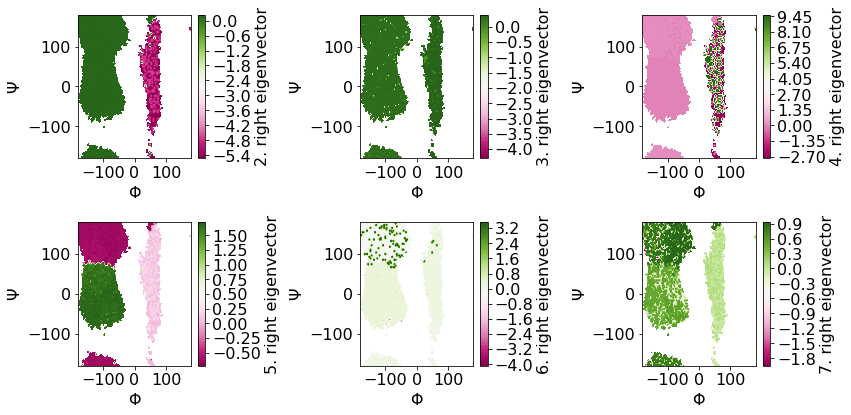

In [341]:
eigvec = msm.eigenvectors_right()
print('first eigenvector is one: {} (min={}, max={})'.format(
    np.allclose(eigvec[:, 0], 1, atol=1e-15), eigvec[:, 0].min(), eigvec[:, 0].max()))

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    pyemma.plots.plot_contour(
        *VAL_dihedral_AV.T, eigvec[dtrajs_AV_kmeans, i + 1], ax=ax, cmap='PiYG',
        cbar_label='{}. right eigenvector'.format(i + 2), mask=True)
    #ax.scatter(*cluster_AV_kmeans.cluster_centers.T, s=15, c='C1')
    ax.set_xlabel('$\Phi$')
    ax.set_ylabel('$\Psi$')
fig.tight_layout()

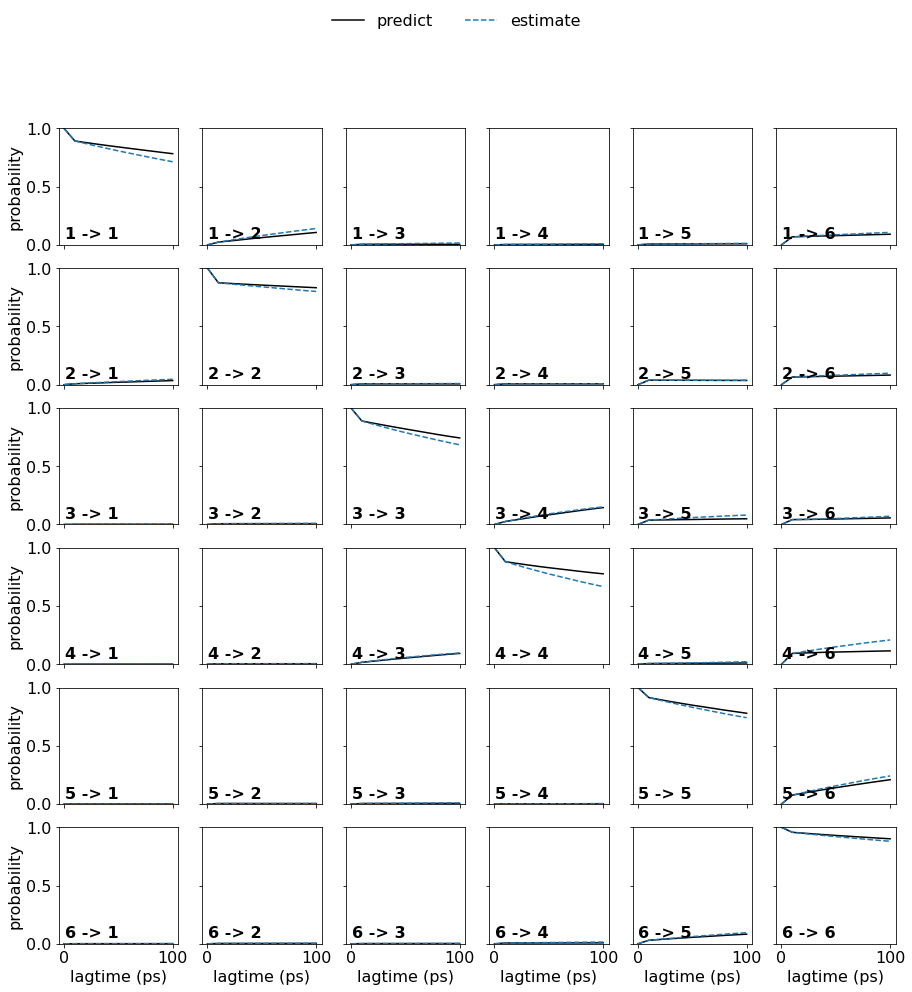

In [342]:
test_model = MaximumLikelihoodMSM(lagtime=10).fit_fetch(dtrajs_AV_kmeans);
AV_kmeans_models = []
for lagtime in [10, 20, 30, 40, 50, 80, 90, 100]:
    AV_kmeans_models.append(MaximumLikelihoodMSM(lagtime=lagtime).fit_fetch(dtrajs_AV_kmeans))
ck_test = test_model.ck_test(AV_kmeans_models, n_metastable_sets=6)
plot_ck_test(ck_test, xlabel='lagtime (ps)', sharey=True);

### PCCA Method

In [346]:
pcca = msm.pcca(6)
for i, s in enumerate(pcca.sets):
    print('π_{} = {:f}'.format(i + 1, msm.stationary_distribution[s].sum()))

π_1 = 0.008664
π_2 = 0.025551
π_3 = 0.027743
π_4 = 0.042857
π_5 = 0.252690
π_6 = 0.642495


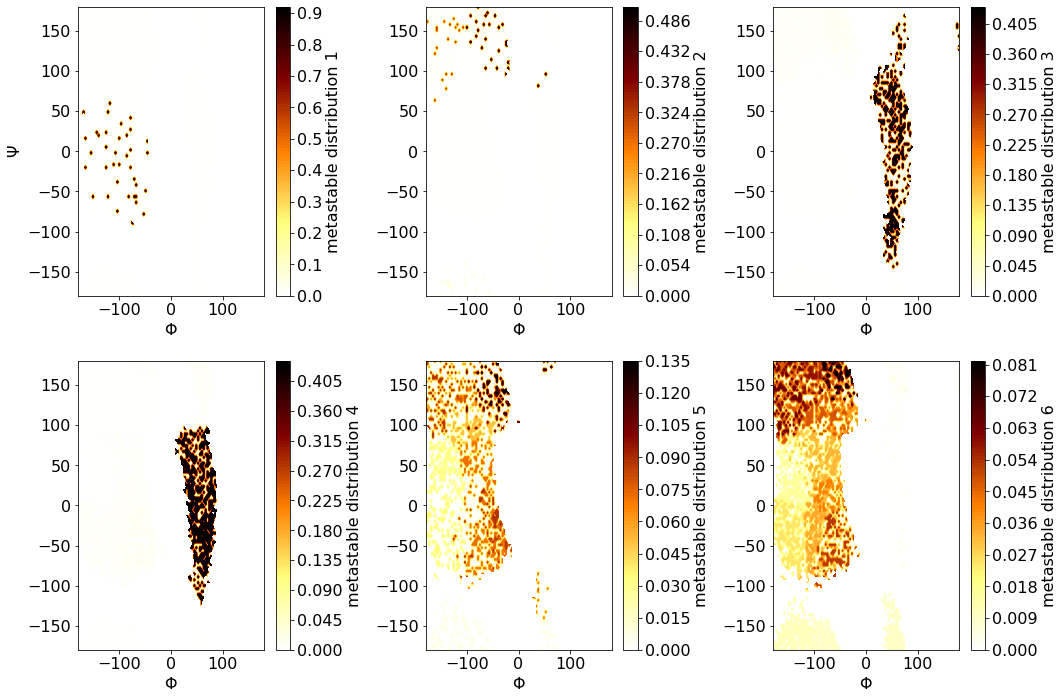

In [332]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, ax in enumerate(axes.flat):
    pyemma.plots.plot_contour(
        *ALA_dihedral_AV.T,
        pcca.metastable_distributions[i][dtrajs_AV_kmeans],
        ax=ax,
        cmap='afmhot_r', 
        mask=True,
        cbar_label='metastable distribution {}'.format(i + 1))
    ax.set_xlabel('$\Phi$')
axes[0,0].set_ylabel('$\Psi$')
fig.tight_layout()

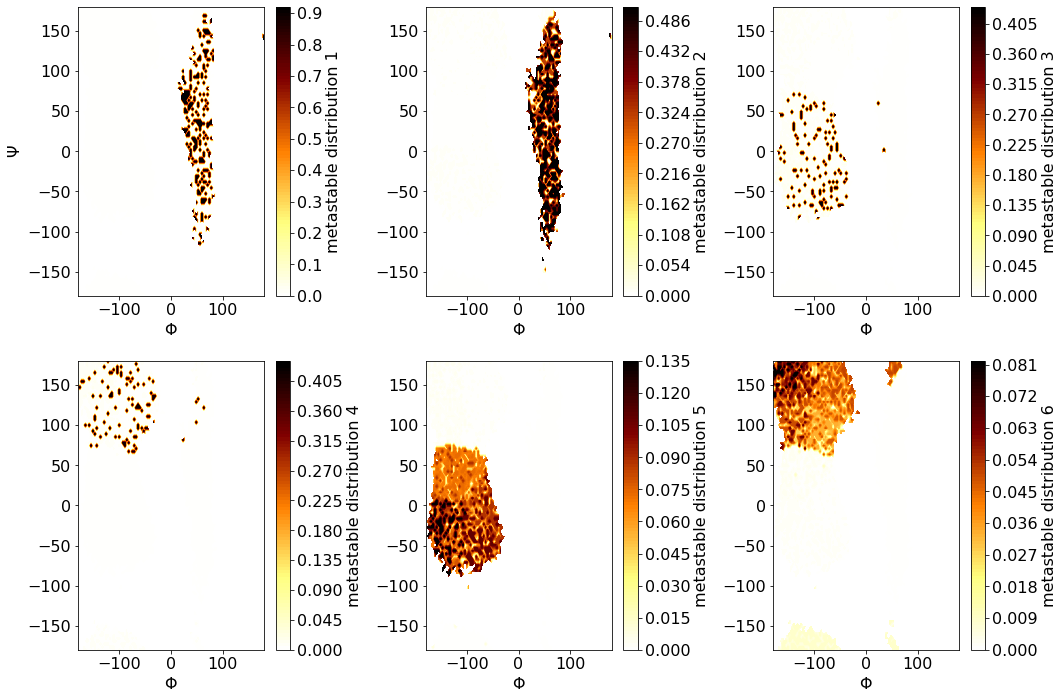

In [299]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, ax in enumerate(axes.flat):
    pyemma.plots.plot_contour(
        *VAL_dihedral_AV.T,
        pcca.metastable_distributions[i][dtrajs_AV_kmeans],
        ax=ax,
        cmap='afmhot_r', 
        mask=True,
        cbar_label='metastable distribution {}'.format(i + 1))
    ax.set_xlabel('$\Phi$')
axes[0,0].set_ylabel('$\Psi$')
fig.tight_layout()